<a href="https://colab.research.google.com/github/cirisleysteinberg-bit/MVP-1-Machine-Learning-Analytics/blob/main/MVP1_PUC_Machine_Learning_Analytics_PAASEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Cirisley Ferreira de Moraes  
**Matrícula:** 4052026000477  
**Data:** Julho/2026  
**Dataset:** Base histórica de acidentes e indicadores de segurança do trabalho no SEP

**Tipo de problema:** Classificação binária  

---

# Predição de Acidentes com Afastamento no Sistema Elétrico de Potência (SEP) utilizando Machine Learning

O objetivo é apresentar um fluxo completo e reprodutível de Machine Learning, contemplando definição do problema, entendimento dos dados, preparação, modelagem, avaliação, otimização, análise crítica e conclusão.

# 1. Introdução



## 1.1 Descrição do problema

O Sistema Elétrico de Potência (SEP) brasileiro é um dos maiores e mais complexos do mundo, composto por milhares de quilômetros de linhas de transmissão, centenas de subestações e usinas hidrelétricas, térmicas, eólicas e solares responsáveis pelo fornecimento contínuo de energia para o país. A operação e a manutenção desses ativos exigem a execução diária de atividades em ambientes de elevado risco, envolvendo eletricidade, trabalho em altura, espaços confinados, equipamentos de grande porte e sistemas energizados.

Apesar da evolução das normas regulamentadoras, dos investimentos em tecnologias, procedimentos operacionais e programas de capacitação, os acidentes de trabalho continuam sendo um dos principais desafios para o setor elétrico. A gravidade desses eventos pode resultar em lesões incapacitantes, fatalidades, interrupções operacionais, perdas financeiras e impactos significativos para as organizações e para a sociedade.

Nos últimos anos, outro fator tem aumentado a complexidade da gestão da segurança: o elevado índice de turnover da mão de obra, especialmente entre empresas contratadas. A constante renovação das equipes faz com que muitos profissionais ingressem nas atividades com pouca experiência prática no SEP e baixo nível de conhecimento sobre os riscos inerentes às instalações elétricas. Essa realidade pode comprometer a correta percepção dos perigos, o entendimento das barreiras de segurança e o cumprimento rigoroso dos procedimentos operacionais, aumentando a exposição aos riscos críticos.

Atualmente, a gestão desses eventos é predominantemente reativa, concentrando esforços na investigação das ocorrências após sua materialização. Embora essa abordagem seja essencial para identificação das causas e implementação de ações corretivas, existe uma oportunidade de evoluir para um modelo mais preventivo, utilizando técnicas de Ciência de Dados e Machine Learning para identificar padrões de risco antes da ocorrência de acidentes mais graves.

Nesse contexto, este projeto propõe o desenvolvimento de um modelo de Machine Learning capaz de prever a probabilidade de um acidente de trabalho resultar em afastamento do colaborador, utilizando informações disponíveis no momento do registro do evento, como empresa, tipo de atividade, localização, potencial do acidente, grau de risco, agente causador, horário da ocorrência e demais características operacionais.

A solução proposta destina-se às áreas de Segurança do Trabalho, Operação, Manutenção e Gestão de Ativos, fornecendo uma ferramenta de apoio à tomada de decisão baseada em dados. O modelo poderá auxiliar na identificação antecipada de cenários mais críticos, permitindo direcionar ações preventivas, priorizar inspeções, reforçar treinamentos, revisar procedimentos e otimizar a alocação de recursos.

Espera-se, como resultado deste trabalho, demonstrar que a aplicação de técnicas de Machine Learning sobre dados históricos de acidentes pode transformar informações operacionais em inteligência para a gestão da segurança, contribuindo para a redução da ocorrência de acidentes graves, fortalecimento da cultura de prevenção, melhoria dos indicadores de desempenho em Segurança e Saúde no Trabalho (SST) e aumento da confiabilidade operacional das empresas que atuam no Sistema Elétrico de Potência brasileiro.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a ocorrência de acidentes com afastamento em atividades do setor elétrico, utilizando dados históricos de acidentes e características associadas aos eventos.

Para isso, serão comparadas uma abordagem BASELINE, baseada em REGRESSÃO LOGISTICA, e um MODELO CANDIDATO, baseado em RANDOM FOREST, com posterior otimização de hiperparâmetros e discussão crítica dos resultados.

## 1.3 Tipo de problema

**Tipo escolhido:** Classificação binária.

O problema abordado consiste em prever se um acidente de trabalho resultará ou não em AFASTAMENTO do colaborador. Dessa forma, a variável de interesse é categórica e possui duas classes possíveis:

- **Sim:** houve afastamento;
- **Não:** não houve afastamento.

Portanto, trata-se de uma tarefa de **classificação supervisionada**, pois o modelo será treinado a partir de exemplos históricos já rotulados.

Não se trata de regressão, pois o objetivo não é prever um valor numérico contínuo. Também não se trata de clusterização, pois existe uma variável alvo conhecida. O problema também não foi tratado como série temporal, pois o objetivo não é prever valores futuros respeitando uma ordem temporal específica.

## 1.4 Premissas, hipóteses e critérios de sucesso

### Hipóteses iniciais

**Hipótese 1:** As características registradas no momento do acidente, como tipo de ocorrência, agente causador, grau de risco, potencial, localidade e horário, possuem relação com a probabilidade de o acidente gerar afastamento.

**Hipótese 2:** Modelos de Machine Learning conseguem identificar padrões nos dados históricos de acidentes e apresentar desempenho superior a um modelo baseline simples.

**Hipótese 3:** As variáveis mais relevantes para o modelo podem apoiar a gestão de segurança do trabalho na priorização de ações preventivas e na identificação de fatores críticos.

### Critérios de sucesso

**Métrica principal:** F1-score, pois o problema envolve classificação binária e pode haver desbalanceamento entre acidentes com e sem afastamento.

**Resultado mínimo esperado:** O modelo candidato deve apresentar desempenho superior ao baseline, especialmente em F1-score e Recall para a classe “Sim”, que representa acidentes com afastamento.

**Restrição prática:** O modelo deve ser simples, interpretável, executável em Google Colab e sem alto custo computacional.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne as importações, a configuração de seed e informações básicas sobre o ambiente de execução.

In [ ]:
# ======================
# 2. Ambiente e bibliotecas
# ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer
)

import joblib
import sklearn

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-Learn:", sklearn.__version__)

Pandas: 2.2.2
NumPy: 2.0.2
Scikit-Learn: 1.6.1


## 2.1 Dependências adicionais

Não foram necessárias dependências adicionais via `pip install`. O projeto utiliza bibliotecas amplamente disponíveis no Google Colab, como Pandas, NumPy, Matplotlib, Seaborn e Scikit-Learn.

Essa decisão reduz o risco de incompatibilidade no momento da correção e mantém o notebook simples e reprodutível.

## 2.2 Funções auxiliares

As funções abaixo foram criadas para reduzir repetição de código e padronizar a avaliação dos modelos.

In [ ]:
# ======================
# 2.2 Funções auxiliares
# ======================

def avaliar_classificacao(nome_modelo, y_true, y_pred, tempo_treino=None):
    """Retorna um dicionário com métricas de classificação para a classe positiva 'Sim'."""
    return {
        "Modelo": nome_modelo,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label="Sim", zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label="Sim", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, pos_label="Sim", zero_division=0),
        "Tempo de treino (s)": tempo_treino
    }


def plotar_matriz_confusao(y_true, y_pred, titulo="Matriz de Confusão"):
    """Exibe matriz de confusão com rótulos Sim/Não."""
    labels = ["Não", "Sim"]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(values_format="d")
    plt.title(titulo)
    plt.show()


def obter_colunas_existentes(df, colunas_candidatas):
    """Seleciona apenas colunas existentes no DataFrame."""
    return [col for col in colunas_candidatas if col in df.columns]


def salvar_figura(nome_arquivo):
    """Salva figura atual com configuração adequada."""
    plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Nome do dataset:** Base histórica de acidentes e indicadores de segurança do trabalho no setor elétrico.

A base foi escolhida por representar um problema real de segurança do trabalho, permitindo aplicar técnicas de Machine Learning em um contexto de elevado impacto humano, operacional e gerencial.

O dataset utilizado neste MVP deve estar anonimizado, sem informações pessoais identificáveis como nome, matrícula, CPF, dados médicos ou informações sensíveis de trabalhadores. A análise deve ser realizada exclusivamente com atributos operacionais dos eventos, respeitando princípios de privacidade e confidencialidade.

## 3.2 Carga dos dados

A célula abaixo carrega os dados a partir de uma URL pública. Para facilitar seus testes locais, há uma alternativa de leitura do arquivo CSV incluído no pacote, mas a versão final para entrega deve usar a URL pública.

In [ ]:
import pandas as pd
from pathlib import Path

# ======================
# 3.2 Carga dos dados
# ======================

# URL pública do CSV no GitHub.
# Antes da entrega, faça upload do arquivo base_ml_mvp1_acidentes.csv no repositório abaixo.
DATA_URL = "https://raw.githubusercontent.com/cirisleysteinberg-bit/MVP-1-Machine-Learning-Analytics/main/base_ml_mvp1_acidentes.csv"

# Caminho local apenas para testes quando o notebook estiver no mesmo diretório do CSV.
LOCAL_CSV = "base_ml_mvp1_acidentes.csv"

df = None # Inicializa df para None
error_message = None

try:
    # Usando engine='python' e on_bad_lines='skip' para lidar com ParserError
    df = pd.read_csv(DATA_URL, engine='python', on_bad_lines='skip')
    print("Dataset carregado pela URL pública do GitHub.")
except Exception as e_url:
    error_message = f"Erro ao carregar pela URL: {e_url}"
    print(f"Aviso: {error_message}")
    if Path(LOCAL_CSV).exists():
        try:
            # Usando engine='python' e on_bad_lines='skip' também para a leitura local
            df = pd.read_csv(LOCAL_CSV, engine='python', on_bad_lines='skip')
            print("Dataset carregado localmente para teste.")
            print("Para entrega, confirme o upload do CSV no GitHub e atualize DATA_URL.")
        except Exception as e_local:
            error_message += f"\nErro ao carregar localmente: {e_local}"
            raise RuntimeError(
                f"Não foi possível carregar o dataset. {error_message}"
            ) from e_local
    else:
        raise RuntimeError(
            f"Não foi possível carregar o dataset. {error_message}\nO arquivo local '{LOCAL_CSV}' não foi encontrado."
        ) from e_url

if df is None:
    raise RuntimeError("Não foi possível carregar o dataset por nenhum método disponível.")

display(df.head())
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Aviso: Erro ao carregar pela URL: HTTP Error 404: Not Found
Dataset carregado localmente para teste.
Para entrega, confirme o upload do CSV no GitHub e atualize DATA_URL.


,Ano,Mês,Dia,Dia da Semana,Hora,Empregado,Empresa,Segmento,Tipo de Trabalho,Local,...,Compromissos (Regra de Ouro),Causa raiz 1,Causa raiz 2,Hora_Inicial,Mes_Num,Ano_Num,Afastamento_Target,Dias Perdidos,Dias Debitados,Classificação;;;
0,2023,12,12.0,Terça- feira,07:00 - 08:00,Próprio,ANORTE,Adm,Individual,NaN,...,8 - Veículos e Equipamentos Móveis,NaN,NaN,7.0,12.0,2023.0,Sim,50,0,Trajeto com afastamento;;;
1,2025,7,28.0,Segunda - feira,06:00 - 07:00,Terceiro,ASUDESTE,Transmissão,Individual,Empresa,...,2 - Percepção de Risco,(em investigação),NaN,6.0,7.0,2025.0,Sim,6,0,Trajeto com afastamento;;;
2,2025,8,7.0,Quinta - feira,10:00 - 11:00,Terceiro,ANORDESTE,Logistica,Individual,Empresa,...,Outros,NaN,NaN,10.0,8.0,2025.0,Não,NaN,NaN,Quase Acidente;;;
3,2022,7,29.0,Sexta-feira,14:00 - 15:00,Terceiro,ASUL,Transmissão,Equipe,Empresa,...,2 - Percepção de Risco,-,-,14.0,7.0,2022.0,Sim,1,1,Típico com afastamento;;;
4,2023,10,20.0,Quinta - feira,11:00 - 12:00,Terceiro,ANORTE,Transmissão,Dupla,Empresa,...,3 - Trabalho em Altura,Não amarração de escada,Escada sob piso escorregadio,11.0,10.0,2023.0,Não,NaN,0,Típico sem afastamento;;;


Linhas: 1185
Colunas: 33


Vamos verificar os tipos de dados e a presença de valores nulos em cada coluna do DataFrame usando `df.info()` e `df.isnull().sum()`.

In [ ]:
print("Informações do DataFrame (tipos de dados e contagem de não-nulos):")
df.info()

print("\nContagem de valores nulos por coluna:")
display(df.isnull().sum().sort_values(ascending=False).to_frame(name='valores_nulos'))

Informações do DataFrame (tipos de dados e contagem de não-nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185 entries, 0 to 1184
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ano                           1185 non-null   object 
 1   Mês                           1180 non-null   object 
 2   Dia                           1178 non-null   float64
 3   Dia da Semana                 1178 non-null   object 
 4   Hora                          1171 non-null   object 
 5   Empregado                     1177 non-null   object 
 6   Empresa                       1178 non-null   object 
 7   Segmento                      1178 non-null   object 
 8   Tipo de Trabalho              1152 non-null   object 
 9   Local                         1139 non-null   object 
 10  Município                     1178 non-null   object 
 11  Estado                        1178 non-null   object 


,valores_nulos
Causa raiz 2,879
Causa raiz 1,633
Dias Perdidos,596
Parte do Corpo Atingida,578
Dias Debitados,547
Gravidade,456
Tipo de Lesão,331
Agente Causador,317
Gerência,126
Gerência Executiva,82


In [ ]:
print('Verificando e corrigindo linhas malformadas na coluna "Ano"...')

# Identifica linhas onde a coluna 'Ano' contém múltiplas informações separadas por vírgulas.
# Esta é uma heurística para encontrar linhas como a que estava no índice 4 do df.head().
malformed_rows_mask = df['Ano'].astype(str).str.contains(',', na=False)

if malformed_rows_mask.any():
    print(f"Encontradas {malformed_rows_mask.sum()} linhas malformadas na coluna 'Ano'. Corrigindo...")

    # Itera sobre as linhas malformadas e tenta re-parsing
    for idx in df[malformed_rows_mask].index:
        malformed_string = df.loc[idx, 'Ano']

        # Divide a string em suas partes assumidas. O número 5 no split indica no máximo 6 partes.
        # As partes esperadas são: Ano, Mês, Dia, Dia da Semana, Hora, Empregado (e o resto, se houver)
        parts = malformed_string.split(',', 5)

        # Atribui as partes às colunas corretas
        if len(parts) > 0: # Ano
            df.loc[idx, 'Ano'] = parts[0]
        if len(parts) > 1: # Mês
            df.loc[idx, 'Mês'] = parts[1]
        if len(parts) > 2: # Dia
            df.loc[idx, 'Dia'] = parts[2]
        if len(parts) > 3: # Dia da Semana
            df.loc[idx, 'Dia da Semana'] = parts[3]
        if len(parts) > 4: # Hora
            df.loc[idx, 'Hora'] = parts[4]
        if len(parts) > 5: # Empregado (pode ser o restante da string)
            df.loc[idx, 'Empregado'] = parts[5]

    print("Correção das linhas malformadas concluída. Exemplo de linhas corrigidas:")
    display(df.loc[malformed_rows_mask].head()) # Mostra as linhas corrigidas para verificação

    # Re-exibe o head do dataframe para mostrar a correção
    print("\nDataFrame.head() após a correção:")
    display(df.head())
else:
    print("Nenhuma linha malformada identificada na coluna 'Ano' que precise de correção específica.")


Verificando e corrigindo linhas malformadas na coluna "Ano"...
Nenhuma linha malformada identificada na coluna 'Ano' que precise de correção específica.


In [ ]:
print("Convertendo a coluna 'Ano' para numérico com errors='coerce'...")
df['Ano'] = pd.to_numeric(df['Ano'], errors='coerce')

print("Verificando os tipos de dados após a conversão da coluna 'Ano':")
df.info()

print("\nContagem de valores nulos atualizada para a coluna 'Ano':")
display(pd.DataFrame({'valores_nulos': [df['Ano'].isnull().sum()]}, index=['Ano']))

Convertendo a coluna 'Ano' para numérico com errors='coerce'...
Verificando os tipos de dados após a conversão da coluna 'Ano':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185 entries, 0 to 1184
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ano                           1178 non-null   float64
 1   Mês                           1180 non-null   object 
 2   Dia                           1178 non-null   float64
 3   Dia da Semana                 1178 non-null   object 
 4   Hora                          1171 non-null   object 
 5   Empregado                     1177 non-null   object 
 6   Empresa                       1178 non-null   object 
 7   Segmento                      1178 non-null   object 
 8   Tipo de Trabalho              1152 non-null   object 
 9   Local                         1139 non-null   object 
 10  Município                     1178 non-null   object

,valores_nulos
Ano,7


In [ ]:
print("Removendo linhas onde a coluna 'Ano' é nula...")
df.dropna(subset=['Ano'], inplace=True)

print(f"Novo número de linhas no DataFrame: {df.shape[0]}")
print(f"Valores nulos na coluna 'Ano' após a remoção: {df['Ano'].isnull().sum()}")

Removendo linhas onde a coluna 'Ano' é nula...
Novo número de linhas no DataFrame: 1178
Valores nulos na coluna 'Ano' após a remoção: 0


In [ ]:
# Identificar as colunas que são features no modelo (excluindo as de leakage)
features_candidatas = [
    "Empresa", "Segmento", "Tipo de Trabalho", "Local", "Município", "Estado",
    "Instalação", "Diretoria", "Gerência Executiva", "Gerência", "Dia da Semana",
    "Hora_Inicial", "Hora", "Agente Causador", "Tipo de Lesão", "Parte do Corpo Atingida",
    "Gravidade", "Potencial", "Grau de Risco", "Compromissos (Regra de Ouro)", "Classificação"
]

colunas_leakage_ou_remover = [
    "Dias Perdidos", "Dias Debitados", "Afastamento_Target", "Afastamento",
    "Empregado", "Ano", "Mês", "Dia", "Ano_Num", "Mes_Num"
]

# Filtrar apenas as features que existem no DataFrame atual e não são de leakage
existing_features_candidatas = [col for col in features_candidatas if col in df.columns]
features = [c for c in existing_features_candidatas if c not in colunas_leakage_ou_remover]

print("Contagem de valores nulos nas colunas que serão usadas como features:")
null_counts_features = df[features].isnull().sum()
display(null_counts_features[null_counts_features > 0].sort_values(ascending=False).to_frame(name='valores_nulos'))

print("\nObservação: colunas com muitos nulos (como 'Parte do Corpo Atingida', 'Gravidade', 'Agente Causador') geralmente são melhor tratadas com imputação para evitar perda excessiva de dados. Seu pipeline de pré-processamento (célula `732a1364`) já inclui o `SimpleImputer` para lidar com isso. Você gostaria de remover linhas apenas de colunas com um número menor de nulos, ou prefere deixar o `SimpleImputer` cuidar de todos eles na etapa de pré-processamento?")

Contagem de valores nulos nas colunas que serão usadas como features:


,valores_nulos
Parte do Corpo Atingida,571
Gravidade,449
Tipo de Lesão,324
Agente Causador,310
Gerência,119
Gerência Executiva,75
Local,39
Tipo de Trabalho,26
Instalação,16
Hora,7



Observação: colunas com muitos nulos (como 'Parte do Corpo Atingida', 'Gravidade', 'Agente Causador') geralmente são melhor tratadas com imputação para evitar perda excessiva de dados. Seu pipeline de pré-processamento (célula `732a1364`) já inclui o `SimpleImputer` para lidar com isso. Você gostaria de remover linhas apenas de colunas com um número menor de nulos, ou prefere deixar o `SimpleImputer` cuidar de todos eles na etapa de pré-processamento?


## 3.3 Visão geral do dataset

Antes da modelagem, são verificadas dimensões, tipos de dados, valores ausentes, duplicatas e possíveis variáveis que não devem entrar no modelo.

In [ ]:
# ======================
# 3.3 Visão geral
# ======================

print("Dimensões do dataset:")
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

print("\nTipos das variáveis:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna:")
display(df.isna().sum().sort_values(ascending=False).to_frame("nulos"))

print("\nQuantidade de registros duplicados:")
print(df.duplicated().sum())

display(df.head())

Dimensões do dataset:
Linhas: 1178
Colunas: 33

Tipos das variáveis:


,tipo
Ano,float64
Mês,object
Dia,float64
Dia da Semana,object
Hora,object
Empregado,object
Empresa,object
Segmento,object
Tipo de Trabalho,object
Local,object



Valores ausentes por coluna:


,nulos
Causa raiz 2,872
Causa raiz 1,626
Dias Perdidos,589
Parte do Corpo Atingida,571
Dias Debitados,540
Gravidade,449
Tipo de Lesão,324
Agente Causador,310
Gerência,119
Gerência Executiva,75



Quantidade de registros duplicados:
24


,Ano,Mês,Dia,Dia da Semana,Hora,Empregado,Empresa,Segmento,Tipo de Trabalho,Local,...,Compromissos (Regra de Ouro),Causa raiz 1,Causa raiz 2,Hora_Inicial,Mes_Num,Ano_Num,Afastamento_Target,Dias Perdidos,Dias Debitados,Classificação;;;
0,2023.0,12,12.0,Terça- feira,07:00 - 08:00,Próprio,ANORTE,Adm,Individual,NaN,...,8 - Veículos e Equipamentos Móveis,NaN,NaN,7.0,12.0,2023.0,Sim,50,0,Trajeto com afastamento;;;
1,2025.0,7,28.0,Segunda - feira,06:00 - 07:00,Terceiro,ASUDESTE,Transmissão,Individual,Empresa,...,2 - Percepção de Risco,(em investigação),NaN,6.0,7.0,2025.0,Sim,6,0,Trajeto com afastamento;;;
2,2025.0,8,7.0,Quinta - feira,10:00 - 11:00,Terceiro,ANORDESTE,Logistica,Individual,Empresa,...,Outros,NaN,NaN,10.0,8.0,2025.0,Não,NaN,NaN,Quase Acidente;;;
3,2022.0,7,29.0,Sexta-feira,14:00 - 15:00,Terceiro,ASUL,Transmissão,Equipe,Empresa,...,2 - Percepção de Risco,-,-,14.0,7.0,2022.0,Sim,1,1,Típico com afastamento;;;
4,2023.0,10,20.0,Quinta - feira,11:00 - 12:00,Terceiro,ANORTE,Transmissão,Dupla,Empresa,...,3 - Trabalho em Altura,Não amarração de escada,Escada sob piso escorregadio,11.0,10.0,2023.0,Não,NaN,0,Típico sem afastamento;;;


In [ ]:
# Criação/validação do target

# Converte Dias Perdidos para numérico, quando a coluna existir.
if "Dias Perdidos" in df.columns:
    df["Dias Perdidos"] = pd.to_numeric(df["Dias Perdidos"], errors="coerce").fillna(0)
    df["Afastamento"] = np.where(df["Dias Perdidos"] > 0, "Sim", "Não")
elif "Afastamento_Target" in df.columns:
    df["Afastamento"] = df["Afastamento_Target"].astype(str)
else:
    raise ValueError("Não foi possível criar o target. Verifique se existe 'Dias Perdidos' ou 'Afastamento_Target'.")

print("Distribuição do target:")
display(df["Afastamento"].value_counts().to_frame("quantidade"))
display((df["Afastamento"].value_counts(normalize=True) * 100).round(2).to_frame("percentual"))

Distribuição do target:


,quantidade
Afastamento,
Não,843
Sim,335


,percentual
Afastamento,
Não,71.56
Sim,28.44


## 3.4 Dicionário de dados

A tabela abaixo apresenta os principais atributos considerados no projeto.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Empresa | Categórica | Empresa ou subsidiária responsável pelo registro | Sim | Pode refletir diferenças operacionais |
| Segmento | Categórica | Segmento de atuação | Sim | Ex.: geração, transmissão, administrativo |
| Tipo de Trabalho | Categórica | Tipo de atividade associada ao evento | Sim | Informação operacional |
| Estado | Categórica | Unidade federativa da ocorrência | Sim | Variável geográfica |
| Município | Categórica | Município da ocorrência | Sim | Variável geográfica |
| Instalação | Categórica | Instalação onde ocorreu o evento | Sim | Pode indicar padrões locais |
| Diretoria | Categórica | Diretoria vinculada ao evento | Sim | Variável organizacional |
| Gerência | Categórica | Gerência relacionada ao evento | Sim | Variável organizacional |
| Dia da Semana | Categórica | Dia da semana da ocorrência | Sim | Pode capturar padrão temporal simples |
| Hora/Hora_Inicial | Numérica/Categórica | Horário ou faixa horária do evento | Sim | Pode indicar padrão temporal |
| Agente Causador | Categórica | Agente relacionado ao acidente | Sim | Potencial fator explicativo |
| Gravidade | Categórica | Classificação da gravidade | Sim | Relevante para o contexto |
| Potencial | Categórica/Numérica | Potencial do evento | Sim | Espera-se forte relação com o target |
| Grau de Risco | Categórica | Nível de risco associado | Sim | Variável explicativa relevante |
| Compromissos (Regra de Ouro) | Categórica | Regra crítica associada | Sim | Apoia análise preventiva |
| Dias Perdidos | Numérica | Dias de afastamento | Não | Usada apenas para criar o target; gera vazamento se entrar no modelo |
| Dias Debitados | Numérica | Dias debitados após o acidente | Não | Consequência do evento; risco de vazamento |
| Afastamento | Alvo | Indica se houve afastamento | Alvo | Classe prevista pelo modelo |

# 4. Análise exploratória dos dados

A análise exploratória busca compreender a distribuição do target, variáveis relevantes, possíveis padrões e impactos na modelagem.

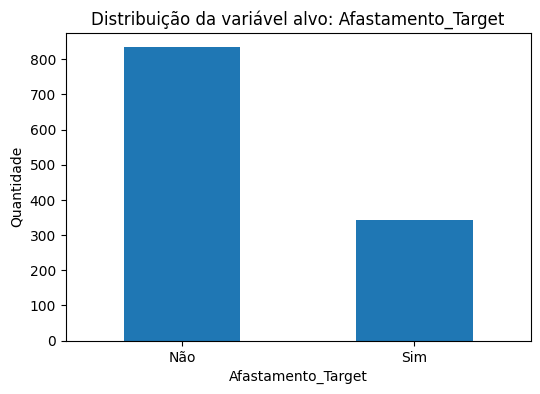

,quantidade
Afastamento_Target,
Não,834
Sim,344


Interpretação: esta distribuição mostra se há desbalanceamento entre acidentes com e sem afastamento. Caso uma classe seja predominante, métricas como Recall e F1-Score são mais adequadas do que apenas Accuracy.


In [ ]:
target_counts = df["Afastamento_Target"].value_counts()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Distribuição da variável alvo: Afastamento_Target")
plt.xlabel("Afastamento_Target")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

display(target_counts.to_frame("quantidade"))

print(
    "Interpretação: esta distribuição mostra se há desbalanceamento entre acidentes com e sem afastamento. "
    "Caso uma classe seja predominante, métricas como Recall e F1-Score são mais adequadas do que apenas Accuracy."
)

In [ ]:
print(df.columns)

Index(['Ano', 'Mês', 'Dia', 'Dia da Semana', 'Hora', 'Empregado', 'Empresa',
       'Segmento', 'Tipo de Trabalho', 'Local', 'Município', 'Estado',
       'Instalação', 'Vice-presidência', 'Diretoria', 'Gerência Executiva',
       'Gerência', 'Agente Causador', 'Tipo de Lesão',
       'Parte do Corpo Atingida', 'Gravidade', 'Potencial', 'Grau de Risco',
       'Compromissos (Regra de Ouro)', 'Causa raiz 1', 'Causa raiz 2',
       'Hora_Inicial', 'Mes_Num', 'Ano_Num', 'Afastamento_Target',
       'Dias Perdidos', 'Dias Debitados', 'Classificação;;;', 'Afastamento'],
      dtype='object')


**NOTA** - Os graficos acima informam que variavel alvo (target) apresentam um desbalanceamento entre as classes. Desaforma as metricas de Recall e F1-Score são mais adequadas do que apenas Accuracy.

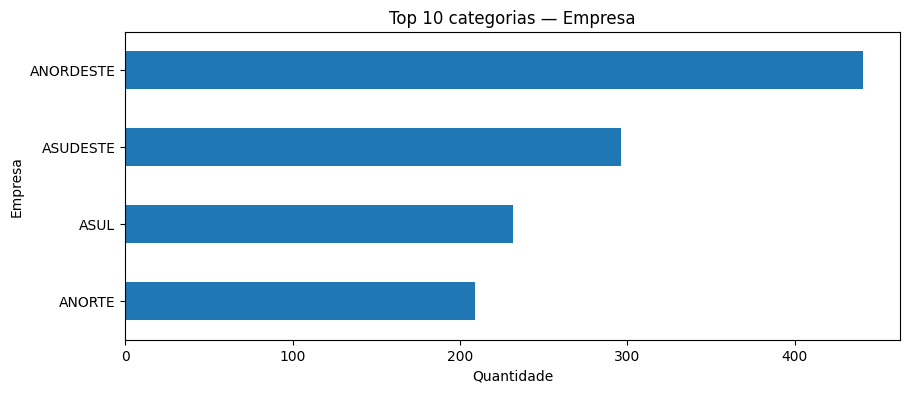

Interpretação: o gráfico de Empresa ajuda a identificar categorias mais frequentes e possíveis concentrações que podem influenciar o modelo.


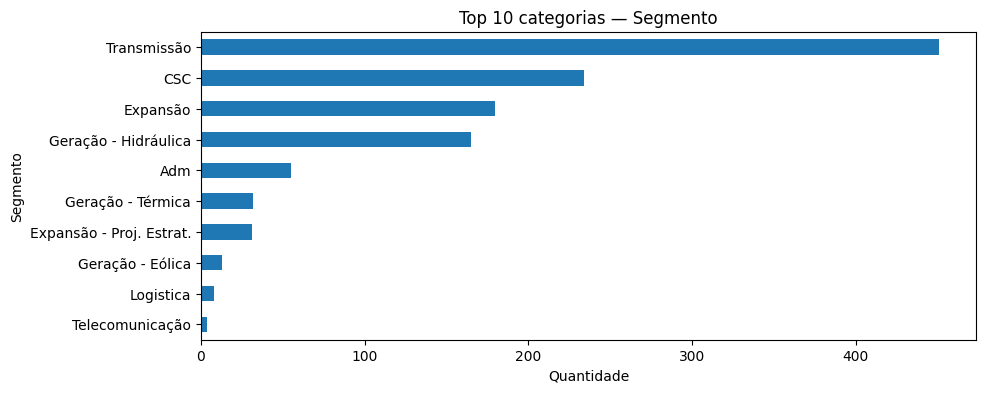

Interpretação: o gráfico de Segmento ajuda a identificar categorias mais frequentes e possíveis concentrações que podem influenciar o modelo.


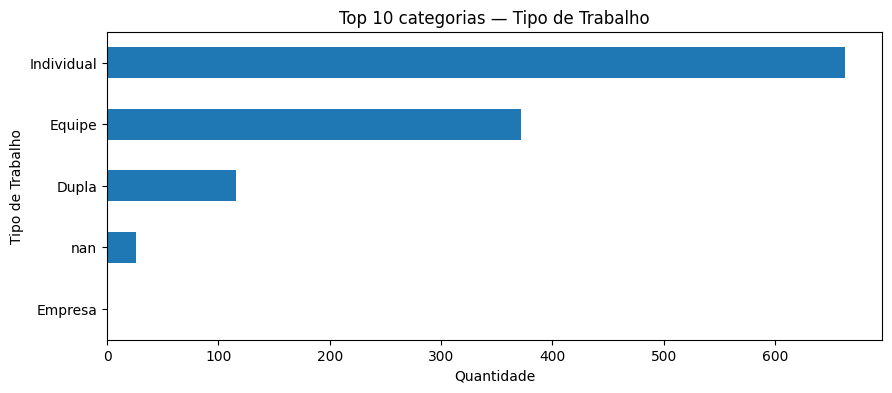

Interpretação: o gráfico de Tipo de Trabalho ajuda a identificar categorias mais frequentes e possíveis concentrações que podem influenciar o modelo.


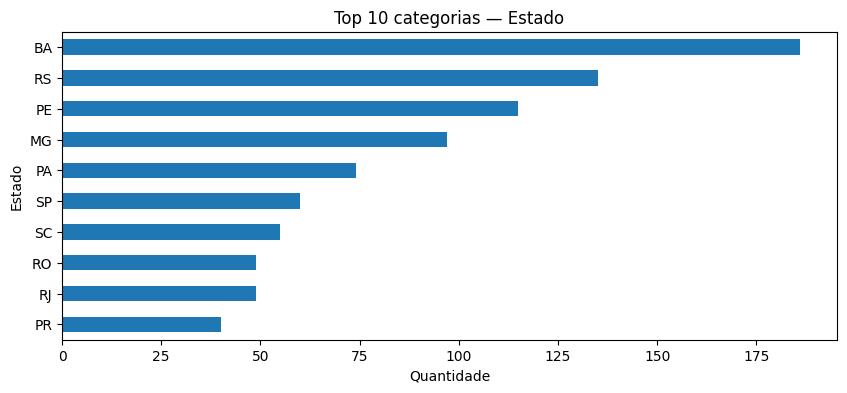

Interpretação: o gráfico de Estado ajuda a identificar categorias mais frequentes e possíveis concentrações que podem influenciar o modelo.


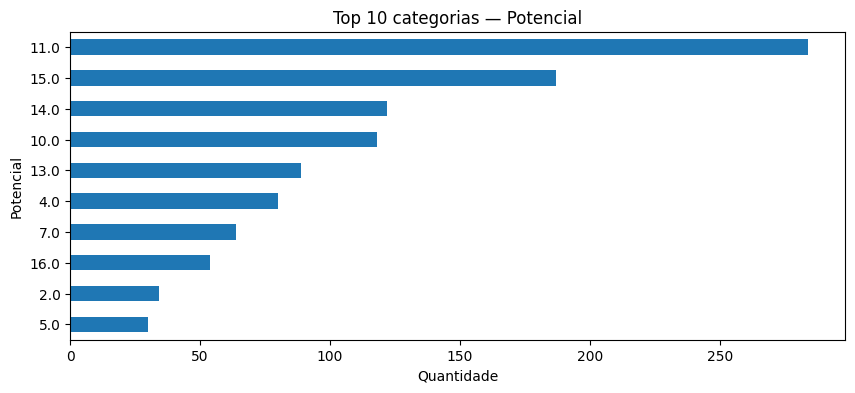

Interpretação: o gráfico de Potencial ajuda a identificar categorias mais frequentes e possíveis concentrações que podem influenciar o modelo.


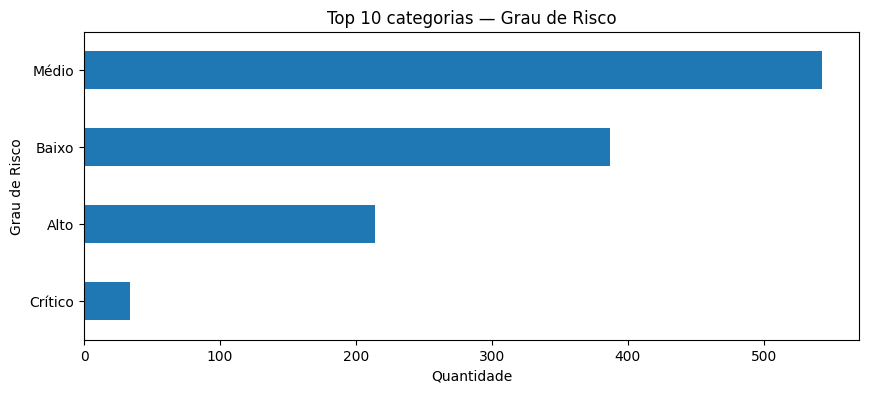

Interpretação: o gráfico de Grau de Risco ajuda a identificar categorias mais frequentes e possíveis concentrações que podem influenciar o modelo.


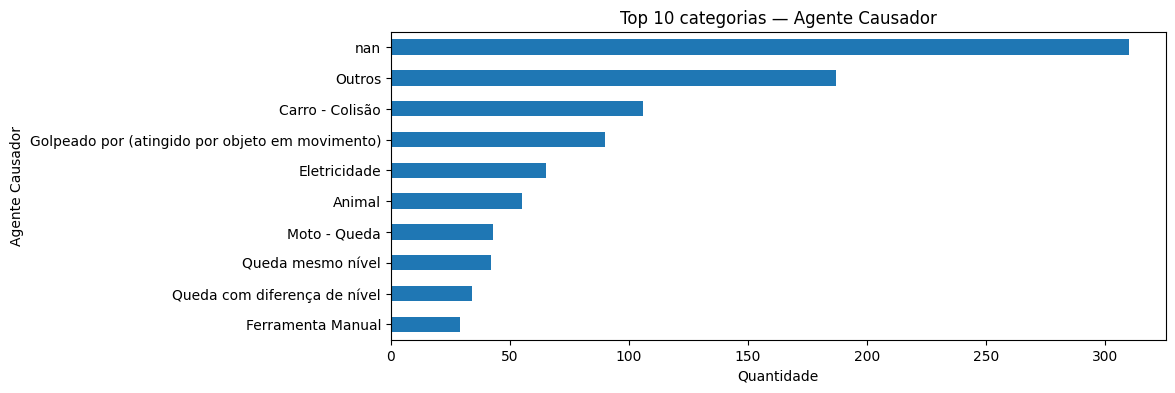

Interpretação: o gráfico de Agente Causador ajuda a identificar categorias mais frequentes e possíveis concentrações que podem influenciar o modelo.


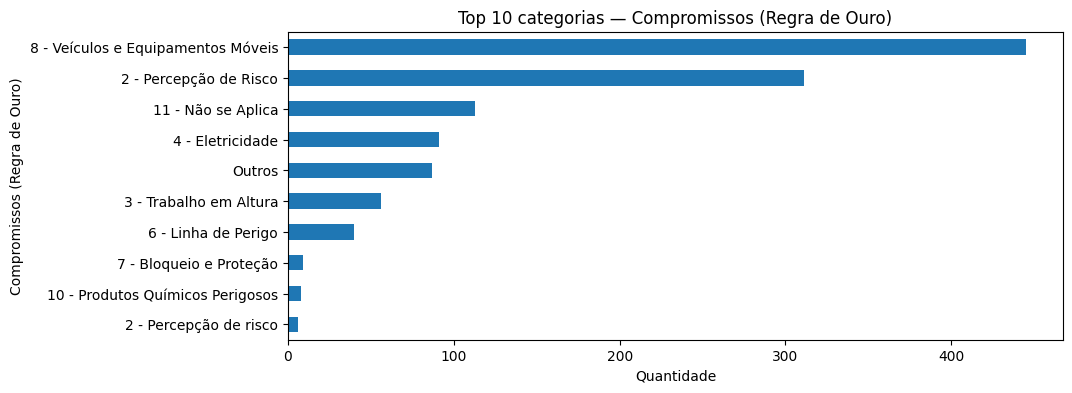

Interpretação: o gráfico de Compromissos (Regra de Ouro) ajuda a identificar categorias mais frequentes e possíveis concentrações que podem influenciar o modelo.


In [ ]:
# ======================
# 4. EDA - Variáveis relevantes
# ======================

colunas_para_graficos = [
    "Empresa", "Segmento", "Tipo de Trabalho", "Estado",
    "Potencial", "Grau de Risco", "Agente Causador",
    "Compromissos (Regra de Ouro)"
]

colunas_para_graficos = obter_colunas_existentes(df, colunas_para_graficos)

for coluna in colunas_para_graficos:
    plt.figure(figsize=(10, 4))
    top_categorias = df[coluna].astype(str).value_counts().head(10).sort_values()
    top_categorias.plot(kind="barh")
    plt.title(f"Top 10 categorias — {coluna}")
    plt.xlabel("Quantidade")
    plt.ylabel(coluna)
    plt.show()

    print(
        f"Interpretação: o gráfico de {coluna} ajuda a identificar categorias mais frequentes "
        "e possíveis concentrações que podem influenciar o modelo."
    )

Afastamento,Não,Sim
Potencial,,
23.0,0.00,100.00
3.0,0.00,100.00
17.0,0.00,100.00
12.0,23.53,76.47
20.0,33.33,66.67
9.0,33.33,66.67
2.0,52.94,47.06
5.0,56.67,43.33
6.0,65.00,35.00


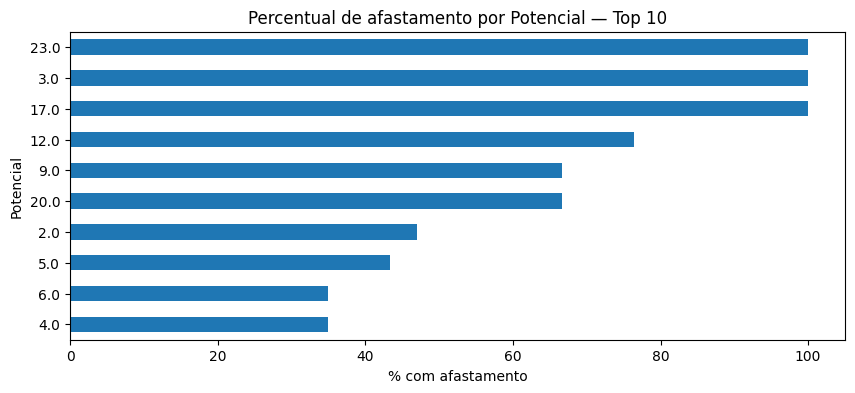

Interpretação: esta análise verifica se determinadas categorias de Potencial apresentam maior proporção de acidentes com afastamento.


Afastamento,Não,Sim
Grau de Risco,,
Crítico,50.00,50.00
Médio,64.64,35.36
Alto,64.95,35.05
Baixo,86.82,13.18


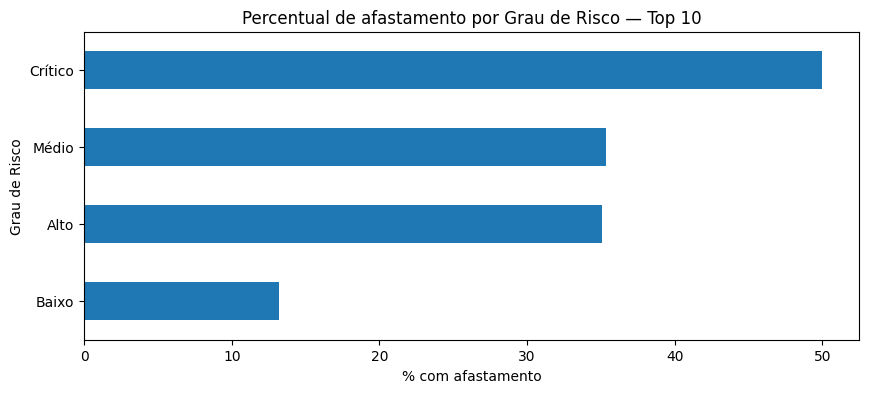

Interpretação: esta análise verifica se determinadas categorias de Grau de Risco apresentam maior proporção de acidentes com afastamento.


Afastamento,Não,Sim
Segmento,,
Adm,49.09,50.91
Melhoria,50.00,50.00
Geração - Térmica,50.00,50.00
Geração - Eólica,69.23,30.77
Transmissão,69.40,30.60
Geração - Hidráulica,71.52,28.48
CSC,75.64,24.36
Expansão,76.11,23.89
Expansão - Proj. Estrat.,96.77,3.23


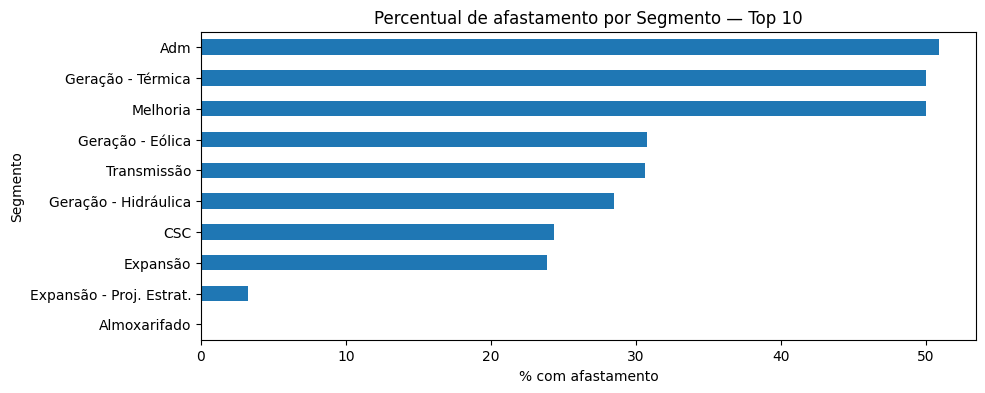

Interpretação: esta análise verifica se determinadas categorias de Segmento apresentam maior proporção de acidentes com afastamento.


Afastamento,Não,Sim
Empresa,,
ASUDESTE,68.58,31.42
ANORDESTE,70.07,29.93
ANORTE,72.73,27.27
ASUL,77.16,22.84


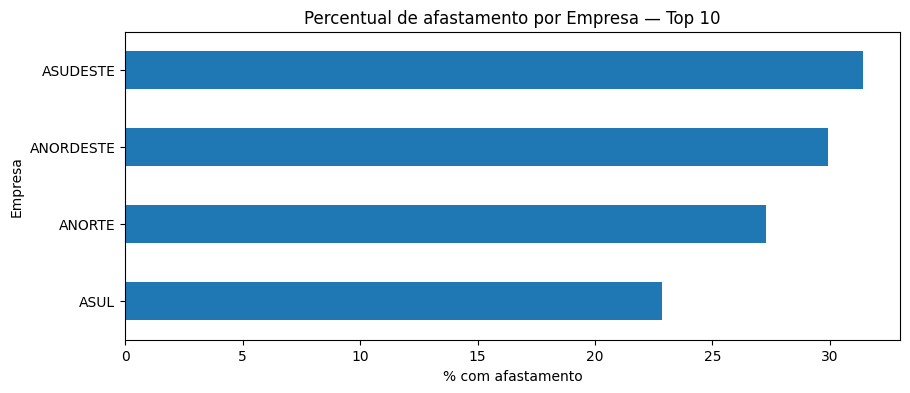

Interpretação: esta análise verifica se determinadas categorias de Empresa apresentam maior proporção de acidentes com afastamento.


Afastamento,Não,Sim
Compromissos (Regra de Ouro),,
7 - Bloqueio e Proteção,44.44,55.56
2 - Percepção de Risco,66.56,33.44
4 - Eletricidade,68.13,31.87
11 - Não se Aplica,68.14,31.86
6 - Linha de Perigo,72.50,27.50
3 - Trabalho em Altura,73.21,26.79
8 - Veículos e Equipamentos Móveis,74.61,25.39
Outros,74.71,25.29
10 - Produtos Químicos Perigosos,100.00,0.00


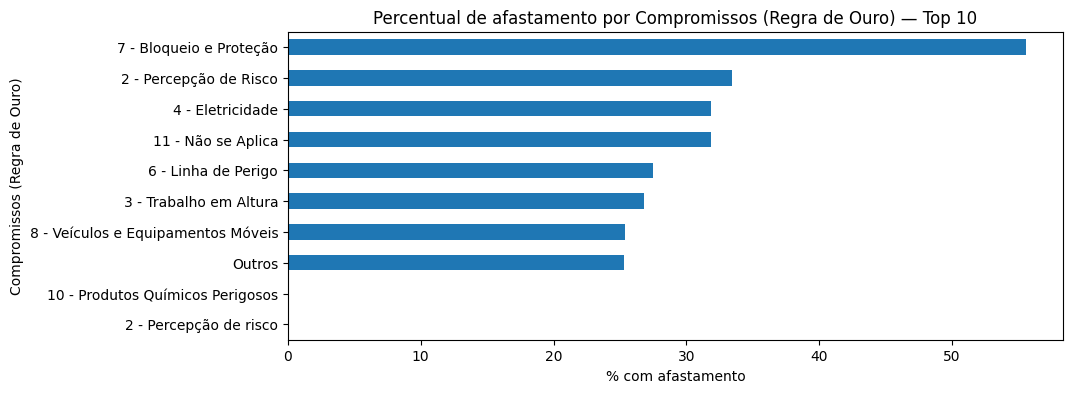

Interpretação: esta análise verifica se determinadas categorias de Compromissos (Regra de Ouro) apresentam maior proporção de acidentes com afastamento.


In [ ]:
# ======================
# 4. Relação entre variáveis e target
# ======================

for coluna in obter_colunas_existentes(df, ["Potencial", "Grau de Risco", "Segmento", "Empresa", "Compromissos (Regra de Ouro)"]):
    tabela = pd.crosstab(df[coluna].astype(str), df["Afastamento"], normalize="index") * 100
    tabela = tabela.round(2)

    display(tabela.sort_values(by="Sim", ascending=False).head(10) if "Sim" in tabela.columns else tabela.head(10))

    if "Sim" in tabela.columns:
        top = tabela.sort_values(by="Sim", ascending=False).head(10).sort_values("Sim")
        plt.figure(figsize=(10, 4))
        top["Sim"].plot(kind="barh")
        plt.title(f"Percentual de afastamento por {coluna} — Top 10")
        plt.xlabel("% com afastamento")
        plt.ylabel(coluna)
        plt.show()

    print(
        f"Interpretação: esta análise verifica se determinadas categorias de {coluna} "
        "apresentam maior proporção de acidentes com afastamento."
    )

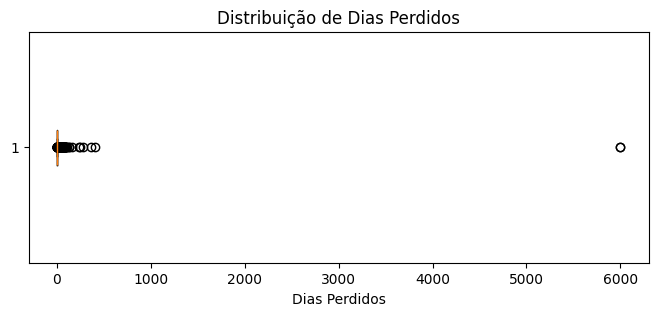

Interpretação: valores extremos em Dias Perdidos são esperados em acidentes de maior gravidade. Entretanto, essa variável não será usada como feature, pois é consequência do acidente.


In [ ]:
# ======================
# 4. Outliers em variáveis numéricas não usadas como feature
# ======================

if "Dias Perdidos" in df.columns:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df["Dias Perdidos"].dropna(), vert=False)
    plt.title("Distribuição de Dias Perdidos")
    plt.xlabel("Dias Perdidos")
    plt.show()

    print(
        "Interpretação: valores extremos em Dias Perdidos são esperados em acidentes de maior gravidade. "
        "Entretanto, essa variável não será usada como feature, pois é consequência do acidente."
    )

## 4.1 Síntese da análise exploratória

A análise exploratória permitiu identificar pontos importantes para a modelagem:

- O target pode apresentar desbalanceamento entre as classes “Sim” e “Não”;
- A maior parte das variáveis é categórica, exigindo codificação antes do treinamento;
- Algumas categorias aparecem com baixa frequência, o que pode impactar a capacidade de generalização;
- Variáveis como potencial do acidente, grau de risco, segmento, agente causador e regras de ouro podem ter relação com acidentes com afastamento;
- Variáveis como Dias Perdidos e Dias Debitados não devem ser utilizadas como features, pois representam consequências do evento e gerariam vazamento de dados;
- Os achados indicam que modelos capazes de capturar relações não lineares, como Random Forest, podem funcionar melhor que um modelo linear simples.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa são definidos o target, as features, as colunas removidas e a divisão entre treino e teste.

In [ ]:
import numpy as np
import pandas as pd

# ======================
# 5. Preparação dos dados
# ======================

# Features candidatas baseadas nas colunas reais disponíveis.
features_candidatas = [
    "Empresa",
    "Segmento",
    "Tipo de Trabalho",
    "Local",
    "Município",
    "Estado",
    "Instalação",
    "Diretoria",
    "Gerência Executiva",
    "Gerência",
    "Dia da Semana",
    "Hora_Inicial",
    "Hora",
    "Agente Causador",
    "Tipo de Lesão",
    "Parte do Corpo Atingida",
    "Gravidade",
    "Potencial",
    "Grau de Risco",
    "Compromissos (Regra de Ouro)",
    "Classificação"
]

# Colunas explicitamente removidas para evitar vazamento de dados ou baixa utilidade preditiva.
colunas_leakage_ou_remover = [
    "Dias Perdidos",
    "Dias Debitados",
    "Afastamento", # 'Afastamento_Target' will be the target 'y'
    "Empregado",
    "Ano",
    "Mês",
    "Dia",
    "Ano_Num",
    "Mes_Num"
]

features = obter_colunas_existentes(df, features_candidatas)
features = [c for c in features if c not in colunas_leakage_ou_remover]

X = df[features].copy()

# Set 'Afastamento_Target' as the target variable `y`
y = df["Afastamento_Target"].copy()

print("Features usadas no modelo:")
print(features)
print("\nQuantidade de features:", len(features))
print("\nDistribuição do target:")
display(y.value_counts())

Features usadas no modelo:
['Empresa', 'Segmento', 'Tipo de Trabalho', 'Local', 'Município', 'Estado', 'Instalação', 'Diretoria', 'Gerência Executiva', 'Gerência', 'Dia da Semana', 'Hora_Inicial', 'Hora', 'Agente Causador', 'Tipo de Lesão', 'Parte do Corpo Atingida', 'Gravidade', 'Potencial', 'Grau de Risco', 'Compromissos (Regra de Ouro)']

Quantidade de features: 20

Distribuição do target:


,count
Afastamento_Target,
Não,834
Sim,344


In [ ]:
# Remoção de duplicatas, se houver, mantendo X e y alinhados.
dados_modelo = pd.concat([X, y.rename("Afastamento")], axis=1)
dados_modelo = dados_modelo.drop_duplicates()

# Remover linhas onde o target 'Afastamento' é NaN, pois stratify não aceita valores nulos.
dados_modelo.dropna(subset=["Afastamento"], inplace=True)

X = dados_modelo[features].copy()
y = dados_modelo["Afastamento"].copy()

print("Dimensões após remoção de duplicatas e NaN no target:")
print("X:", X.shape)
print("y:", y.shape)

Dimensões após remoção de duplicatas e NaN no target:
X: (1150, 20)
y: (1150,)


In [ ]:
# Divisão treino/teste com estratificação.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição no treino:")
display(y_train.value_counts(normalize=True).mul(100).round(2).to_frame("%"))

print("\nDistribuição no teste:")
display(y_test.value_counts(normalize=True).mul(100).round(2).to_frame("%"))

Treino: (920, 20)
Teste: (230, 20)

Distribuição no treino:


,%
Afastamento,
Não,70.43
Sim,29.57



Distribuição no teste:


,%
Afastamento,
Não,70.43
Sim,29.57


## 5.1 Justificativa da divisão

Foi utilizada a estratégia **holdout**, com 80% dos registros para treinamento e 20% para teste. Essa abordagem é adequada ao escopo do MVP, pois permite treinar o modelo com a maior parte dos dados e reservar uma parcela independente para avaliação final.

Como o problema é de classificação binária e pode haver desbalanceamento entre as classes, foi utilizada estratificação (`stratify=y`) para preservar a proporção entre acidentes com e sem afastamento nos conjuntos de treino e teste.

O problema não foi tratado como série temporal, portanto não foi necessária divisão baseada em tempo. Além disso, variáveis com risco de vazamento, como Dias Perdidos e Dias Debitados, foram removidas antes da modelagem.

# 6. Pré-processamento e pipeline

Esta seção cria uma sequência reprodutível de tratamento dos dados, ajustando transformações apenas no treino e aplicando no teste.

In [ ]:
# ======================
# 6. Pré-processamento e pipeline
# ======================

variaveis_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
variaveis_categoricas = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variáveis numéricas:", variaveis_numericas)
print("Variáveis categóricas:", variaveis_categoricas)

pipeline_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("padronizador", StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, variaveis_numericas),
        ("cat", pipeline_categorico, variaveis_categoricas)
    ],
    remainder="drop"
)

Variáveis numéricas: ['Hora_Inicial', 'Potencial']
Variáveis categóricas: ['Empresa', 'Segmento', 'Tipo de Trabalho', 'Local', 'Município', 'Estado', 'Instalação', 'Diretoria', 'Gerência Executiva', 'Gerência', 'Dia da Semana', 'Hora', 'Agente Causador', 'Tipo de Lesão', 'Parte do Corpo Atingida', 'Gravidade', 'Grau de Risco', 'Compromissos (Regra de Ouro)']


## 6.1 Decisões de pré-processamento

As variáveis numéricas foram imputadas pela mediana, por ser uma medida robusta a outliers. As variáveis categóricas foram imputadas pela moda, preservando a categoria mais frequente quando há valores ausentes.

Foi utilizado One-Hot Encoding para variáveis categóricas, evitando criar uma ordem artificial entre categorias. O parâmetro `handle_unknown='ignore'` permite que o pipeline lide com categorias que apareçam no teste e não tenham aparecido no treino.

As variáveis numéricas foram padronizadas com StandardScaler, especialmente para beneficiar a Regressão Logística, que é sensível à escala dos atributos.

As transformações foram implementadas por meio de pipelines, garantindo que imputação, codificação e padronização sejam ajustadas apenas no conjunto de treino, reduzindo o risco de vazamento de dados.

# 7. Baseline e modelos candidatos

O baseline ajuda a responder se o modelo realmente aprendeu padrões relevantes ou se o problema é simples.

In [ ]:
# ======================
# 7. Definição dos modelos
# ======================

baseline_dummy = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", DummyClassifier(strategy="most_frequent"))
])

modelo_logistico = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
])

modelo_rf = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(random_state=SEED, class_weight="balanced"))
])

## 7.1 Justificativa dos modelos

Foi utilizado um **DummyClassifier** como referência mínima, pois ele prevê sempre a classe majoritária. Esse baseline ajuda a verificar se os modelos realmente aprendem padrões além da distribuição do target.

A **Regressão Logística** foi utilizada como baseline estatístico por ser simples, interpretável e amplamente aplicada a problemas de classificação binária.

O **Random Forest** foi escolhido como modelo candidato por sua capacidade de capturar relações não lineares e interações entre variáveis, características esperadas em problemas de segurança do trabalho. Além disso, o modelo permite análise de importância das variáveis e possui custo computacional adequado ao Google Colab.

# 8. Treinamento e avaliação inicial

Nesta seção, os modelos são treinados e comparados no conjunto de teste. O teste será usado apenas para avaliação inicial e final; ajustes de hiperparâmetros serão feitos com validação cruzada no conjunto de treino.

In [ ]:
# ======================
# 8. Treinamento inicial
# ======================

resultados_lista = []

modelos_iniciais = {
    "Dummy - Classe majoritária": baseline_dummy,
    "Regressão Logística": modelo_logistico,
    "Random Forest": modelo_rf
}

predicoes = {}

for nome, modelo in modelos_iniciais.items():
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tempo = time.time() - inicio

    y_pred = modelo.predict(X_test)
    predicoes[nome] = y_pred

    resultados_lista.append(avaliar_classificacao(nome, y_test, y_pred, tempo))

resultados_iniciais = pd.DataFrame(resultados_lista)
display(resultados_iniciais.sort_values("F1-Score", ascending=False).round(4))

,Modelo,Accuracy,Precision,Recall,F1-Score,Tempo de treino (s)
1,Regressão Logística,0.8565,0.7333,0.8088,0.7692,0.0296
2,Random Forest,0.8565,0.7778,0.7206,0.7481,0.3200
0,Dummy - Classe majoritária,0.7043,0.0000,0.0000,0.0000,0.0208


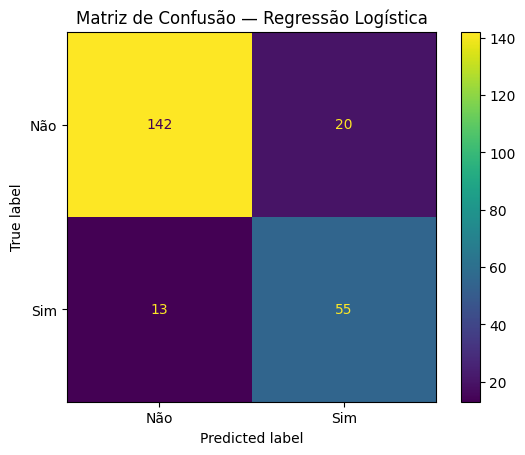

In [ ]:
# Matriz de confusão para o melhor modelo inicial por F1-Score.
melhor_inicial_nome = resultados_iniciais.sort_values("F1-Score", ascending=False).iloc[0]["Modelo"]
plotar_matriz_confusao(y_test, predicoes[melhor_inicial_nome], f"Matriz de Confusão — {melhor_inicial_nome}")

## 8.1 Análise dos resultados iniciais

A comparação inicial permite verificar se os modelos superam o baseline simples. Como o problema pode apresentar desbalanceamento entre as classes, a avaliação deve priorizar F1-Score e Recall para a classe “Sim”, que representa acidentes com afastamento.

Se o Random Forest apresentar desempenho superior à Regressão Logística, isso sugere que existem relações não lineares ou interações entre variáveis que o modelo linear não captura tão bem. O tempo de treinamento esperado para ambos os modelos é aceitável no Google Colab.

A matriz de confusão ajuda a identificar erros críticos. No contexto de segurança do trabalho, os falsos negativos são especialmente importantes, pois representam acidentes com afastamento que foram previstos como sem afastamento.

# 9. Validação e otimização de hiperparâmetros

Nesta etapa será feita uma busca simples de hiperparâmetros para o Random Forest, utilizando validação cruzada apenas sobre o conjunto de treinamento.

In [ ]:
# ======================
# 9. GridSearchCV
# ======================

# Para manter o MVP executável no Colab, foi usada uma busca pequena e objetiva.
menor_classe = y_train.value_counts().min()
n_splits = int(min(3, menor_classe)) if menor_classe >= 2 else 2

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

f1_sim = make_scorer(f1_score, pos_label="Sim", zero_division=0)

param_grid_rf = {
    "modelo__n_estimators": [50, 100],
    "modelo__max_depth": [5, 10],
    "modelo__min_samples_split": [2],
    "modelo__class_weight": ["balanced"]
}

grid_rf = GridSearchCV(
    estimator=modelo_rf,
    param_grid=param_grid_rf,
    scoring=f1_sim,
    cv=cv,
    n_jobs=1,
    return_train_score=True
)

inicio = time.time()
grid_rf.fit(X_train, y_train)
tempo_grid = time.time() - inicio

print("Tempo de otimização:", round(tempo_grid, 2), "segundos")
print("Melhor F1 médio na validação cruzada:", round(grid_rf.best_score_, 4))
print("Melhores parâmetros:")
display(grid_rf.best_params_)

melhor_modelo_rf = grid_rf.best_estimator_
y_pred_rf_otimizado = melhor_modelo_rf.predict(X_test)

resultado_otimizado = avaliar_classificacao(
    "Random Forest Otimizado",
    y_test,
    y_pred_rf_otimizado,
    tempo_grid
)

display(pd.DataFrame([resultado_otimizado]).round(4))

Tempo de otimização: 2.44 segundos
Melhor F1 médio na validação cruzada: 0.8167
Melhores parâmetros:


{'modelo__class_weight': 'balanced',
 'modelo__max_depth': 10,
 'modelo__min_samples_split': 2,
 'modelo__n_estimators': 50}

,Modelo,Accuracy,Precision,Recall,F1-Score,Tempo de treino (s)
0,Random Forest Otimizado,0.8565,0.7273,0.8235,0.7724,2.4448


In [ ]:
# Resultados da busca de hiperparâmetros
resultados_grid = pd.DataFrame(grid_rf.cv_results_)
colunas_grid = [
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_modelo__n_estimators",
    "param_modelo__max_depth",
    "param_modelo__min_samples_split",
    "param_modelo__class_weight"
]

display(
    resultados_grid[colunas_grid]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

,mean_test_score,std_test_score,mean_train_score,param_modelo__n_estimators,param_modelo__max_depth,param_modelo__min_samples_split,param_modelo__class_weight
2,0.816726,0.012057,0.930890,50,10,2,balanced
3,0.812372,0.017730,0.938679,100,10,2,balanced
1,0.788887,0.021401,0.852080,100,5,2,balanced
0,0.782589,0.024300,0.851453,50,5,2,balanced


In [ ]:
# Consolida resultados iniciais + modelo otimizado
resultados_final = pd.concat([
    resultados_iniciais,
    pd.DataFrame([resultado_otimizado])
], ignore_index=True)

resultados_final = resultados_final.sort_values("F1-Score", ascending=False)
display(resultados_final.round(4))

,Modelo,Accuracy,Precision,Recall,F1-Score,Tempo de treino (s)
3,Random Forest Otimizado,0.8565,0.7273,0.8235,0.7724,2.4448
1,Regressão Logística,0.8565,0.7333,0.8088,0.7692,0.0296
2,Random Forest,0.8565,0.7778,0.7206,0.7481,0.3200
0,Dummy - Classe majoritária,0.7043,0.0000,0.0000,0.0000,0.0208


## 9.1 Discussão da otimização

A busca de hiperparâmetros foi propositalmente limitada, considerando o escopo do MVP, o custo computacional e a necessidade de manter o notebook executável no Google Colab.

Foram testados parâmetros relacionados ao número de árvores, profundidade máxima, número mínimo de amostras para divisão dos nós e balanceamento de classes. A métrica escolhida para orientar a busca foi o F1-Score da classe “Sim”.

A otimização permite avaliar se pequenas alterações nos parâmetros melhoram a capacidade de generalização do modelo. Caso a melhora seja pequena, ainda assim a etapa é útil por demonstrar uma seleção mais controlada do modelo final.

# 10. Avaliação final no conjunto de teste

Depois da seleção do melhor modelo, a avaliação final é feita no conjunto de teste, que não foi utilizado para escolher hiperparâmetros.

,Modelo,Accuracy,Precision,Recall,F1-Score,Tempo de treino (s)
3,Random Forest Otimizado,0.8565,0.7273,0.8235,0.7724,2.4448
1,Regressão Logística,0.8565,0.7333,0.8088,0.7692,0.0296
2,Random Forest,0.8565,0.7778,0.7206,0.7481,0.3200
0,Dummy - Classe majoritária,0.7043,0.0000,0.0000,0.0000,0.0208


Relatório de classificação do modelo final:
              precision    recall  f1-score   support

         Não       0.92      0.87      0.90       162
         Sim       0.73      0.82      0.77        68

    accuracy                           0.86       230
   macro avg       0.82      0.85      0.83       230
weighted avg       0.86      0.86      0.86       230



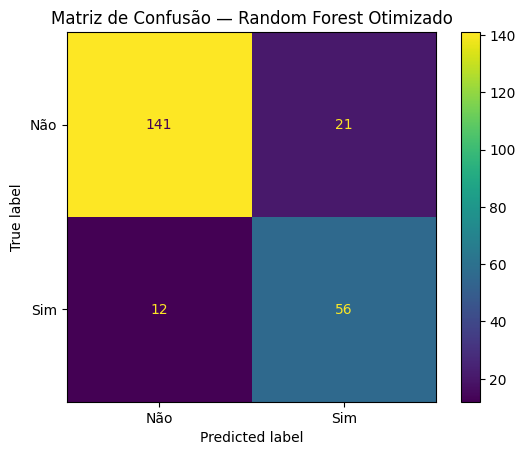

In [ ]:
# ======================
# 10. Avaliação final
# ======================

# Consolida resultados iniciais + modelo otimizado
resultados_final = pd.concat([
    resultados_iniciais,
    pd.DataFrame([resultado_otimizado])
], ignore_index=True)

resultados_final = resultados_final.sort_values("F1-Score", ascending=False)
display(resultados_final.round(4))

print("Relatório de classificação do modelo final:")
print(classification_report(y_test, y_pred_rf_otimizado, zero_division=0))

plotar_matriz_confusao(y_test, y_pred_rf_otimizado, "Matriz de Confusão — Random Forest Otimizado")

## 10.1 Análise de erros e limitações

Os erros mais críticos são os falsos negativos, ou seja, situações em que o modelo prevê que não haverá afastamento, mas o evento real resultou em afastamento. No contexto de segurança do trabalho, esse tipo de erro pode levar à subestimação do risco.

O F1-Score foi utilizado como métrica principal por equilibrar Precision e Recall. O Recall também deve ser observado com atenção, pois mede a capacidade do modelo em identificar corretamente os casos positivos.

Não se deve afirmar que não existe overfitting de forma absoluta. A análise deve comparar o desempenho da validação cruzada com o desempenho no teste. Caso os valores sejam próximos, não há indícios fortes de overfitting. Caso o desempenho no treino seja muito superior ao teste, pode haver sobreajuste.

As principais limitações são:

- base proveniente de uma única organização;
- possível desbalanceamento das classes;
- registros históricos sujeitos a erros de preenchimento;
- ausência de variáveis comportamentais, ambientais e operacionais adicionais;
- risco de menor generalização em empresas ou cenários diferentes.

O modelo não deve ser utilizado isoladamente para tomada de decisão operacional. Ele deve atuar como ferramenta de apoio à análise de especialistas em segurança do trabalho.

# 11. Comparação final dos modelos

A tabela abaixo sintetiza a comparação entre baseline, modelos candidatos e modelo otimizado.

In [ ]:
# ======================
# 11. Comparação final
# ======================

comparacao = resultados_final.copy()

def classificar_tempo(t):
    if pd.isna(t):
        return "Não informado"
    if t < 1:
        return "Muito baixo"
    if t < 10:
        return "Baixo"
    if t < 60:
        return "Médio"
    return "Alto"

comparacao["Tempo de treino"] = comparacao["Tempo de treino (s)"].apply(classificar_tempo)
comparacao["Métrica principal"] = comparacao["F1-Score"].round(4)
comparacao["Outras métricas"] = (
    "Acc=" + comparacao["Accuracy"].round(4).astype(str) +
    " | Prec=" + comparacao["Precision"].round(4).astype(str) +
    " | Recall=" + comparacao["Recall"].round(4).astype(str)
)

observacoes = {
    "Dummy - Classe majoritária": "Referência mínima; prevê a classe mais frequente.",
    "Regressão Logística": "Modelo simples e interpretável; baseline estatístico.",
    "Random Forest": "Captura relações não lineares e interações entre variáveis.",
    "Random Forest Otimizado": "Modelo escolhido se apresentar melhor equilíbrio entre F1, Recall e generalização."
}

comparacao["Observações"] = comparacao["Modelo"].map(observacoes).fillna("Modelo avaliado.")

tabela_final = comparacao[["Modelo", "Métrica principal", "Outras métricas", "Tempo de treino", "Observações"]]
display(tabela_final)

,Modelo,Métrica principal,Outras métricas,Tempo de treino,Observações
3,Random Forest Otimizado,0.7724,Acc=0.8565 | Prec=0.7273 | Recall=0.8235,Baixo,Modelo escolhido se apresentar melhor equilíbr...
1,Regressão Logística,0.7692,Acc=0.8565 | Prec=0.7333 | Recall=0.8088,Muito baixo,Modelo simples e interpretável; baseline estat...
2,Random Forest,0.7481,Acc=0.8565 | Prec=0.7778 | Recall=0.7206,Muito baixo,Captura relações não lineares e interações ent...
0,Dummy - Classe majoritária,0.0000,Acc=0.7043 | Prec=0.0 | Recall=0.0,Muito baixo,Referência mínima; prevê a classe mais frequente.


### Análise da Categoria 'Agente Causador_Outros'

Para investigar a categoria 'Agente Causador_Outros' e identificar possíveis subcategorias, vamos filtrar o DataFrame para os casos em que 'Agente Causador' é 'Outros' e analisar a distribuição de outras variáveis relevantes nesses casos. Isso pode revelar padrões que permitam criar categorias mais específicas.

In [ ]:
# Filtrar o DataFrame para casos onde 'Agente Causador' é 'Outros'
df_outros = df[df['Agente Causador'] == 'Outros'].copy()

print(f"Número de ocorrências com 'Agente Causador_Outros': {df_outros.shape[0]}")

# Analisar outras variáveis categóricas relevantes para identificar padrões
print("\nDistribuição de 'Tipo de Lesão' para 'Agente Causador_Outros':")
display(df_outros['Tipo de Lesão'].value_counts(dropna=False).to_frame())

print("\nDistribuição de 'Parte do Corpo Atingida' para 'Agente Causador_Outros':")
display(df_outros['Parte do Corpo Atingida'].value_counts(dropna=False).to_frame())

print("\nDistribuição de 'Local' para 'Agente Causador_Outros':")
display(df_outros['Local'].value_counts(dropna=False).to_frame())

print("\nDistribuição de 'Tipo de Trabalho' para 'Agente Causador_Outros':")
display(df_outros['Tipo de Trabalho'].value_counts(dropna=False).to_frame())

print("\nDistribuição de 'Gravidade' para 'Agente Causador_Outros':")
display(df_outros['Gravidade'].value_counts(dropna=False).to_frame())

print("\nDistribuição do 'Afastamento_Target' para 'Agente Causador_Outros':")
display(df_outros['Afastamento_Target'].value_counts(normalize=True).mul(100).round(2).to_frame())

Número de ocorrências com 'Agente Causador_Outros': 187

Distribuição de 'Tipo de Lesão' para 'Agente Causador_Outros':


,count
Tipo de Lesão,
Sem Lesões,106
Lesão,17
Outros,16
NaN,10
Perda / Diminuição dos Sentidos,10
Traumatismo,5
Fratura,5
Lombalgia de Esforço,5
-,3



Distribuição de 'Parte do Corpo Atingida' para 'Agente Causador_Outros':


,count
Parte do Corpo Atingida,
NaN,96
Não se Aplica,17
-,13
Face,9
Mão Direita,6
Braço Direito,6
Partes Múltiplas,5
Coluna,4
Dedo da mão Esquerda,4



Distribuição de 'Local' para 'Agente Causador_Outros':


...

,count
Tipo de Trabalho,
Individual,94
Equipe,71
Dupla,15
NaN,6
Empresa,1



Distribuição de 'Gravidade' para 'Agente Causador_Outros':


,count
Gravidade,
NaN,96
Baixo,49
Médio,36
Alto,5
-,1



Distribuição do 'Afastamento_Target' para 'Agente Causador_Outros':


,proportion
Afastamento_Target,
Não,82.35
Sim,17.65


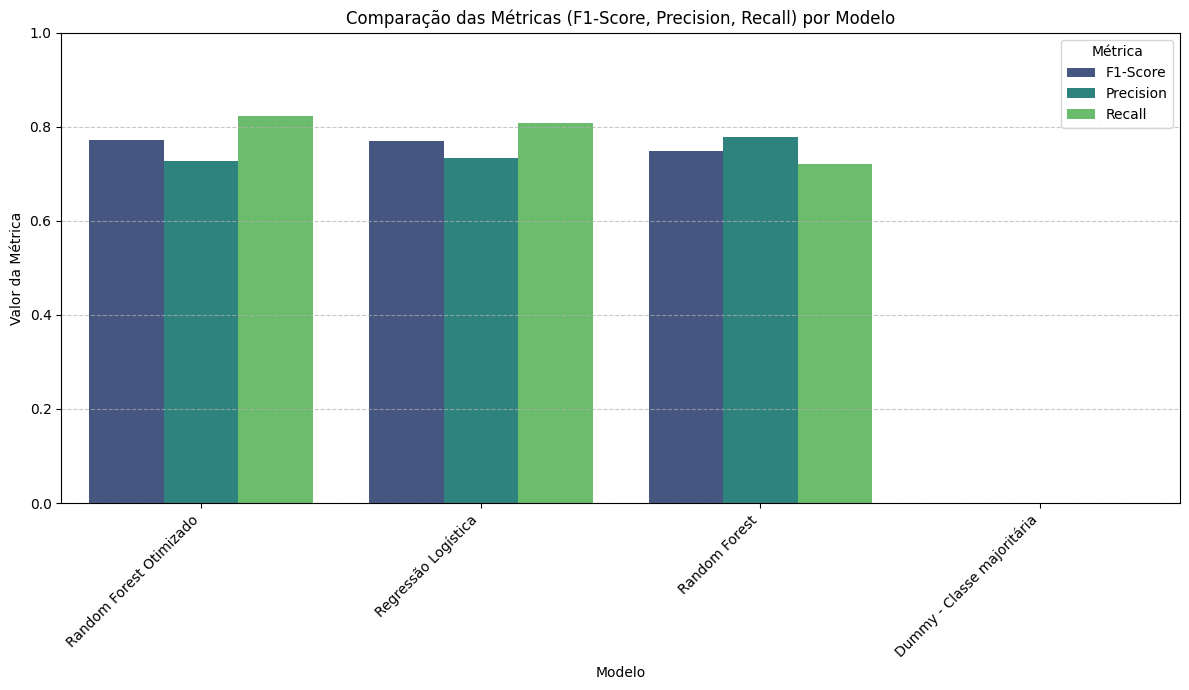

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar os dados para o gráfico comparativo
comparacao_metricas = resultados_final[['Modelo', 'F1-Score', 'Precision', 'Recall']].copy()
comparacao_metricas_long = comparacao_metricas.melt(
    id_vars=['Modelo'],
    var_name='Métrica',
    value_name='Valor'
)

# Criar o gráfico comparativo
plt.figure(figsize=(12, 7))
sns.barplot(data=comparacao_metricas_long, x='Modelo', y='Valor', hue='Métrica', palette='viridis')
plt.title('Comparação das Métricas (F1-Score, Precision, Recall) por Modelo')
plt.xlabel('Modelo')
plt.ylabel('Valor da Métrica')
plt.ylim(0, 1) # As métricas de classificação variam de 0 a 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Métrica')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 20 variáveis mais importantes:


,Variavel,Importancia
1195,cat__Gravidade_Baixo,0.165003
1160,cat__Tipo de Lesão_Sem Lesões,0.135458
1180,cat__Parte do Corpo Atingida_Não se Aplica,0.127974
1196,cat__Gravidade_Médio,0.068166
1131,cat__Agente Causador_Outros,0.033747
1149,cat__Tipo de Lesão_Fratura,0.027351
1,num__Potencial,0.026439
1198,cat__Grau de Risco_Baixo,0.020304
1153,cat__Tipo de Lesão_Luxação,0.014743
1151,cat__Tipo de Lesão_Lesão,0.010091


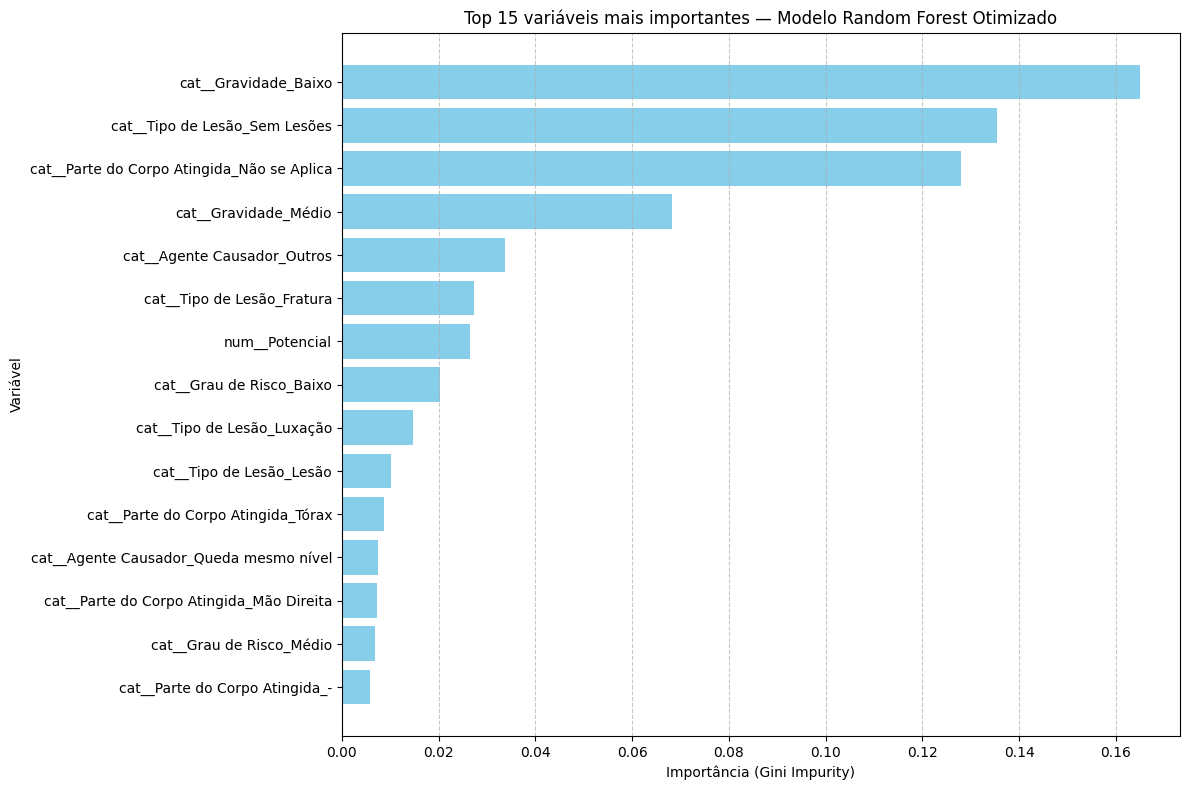

In [ ]:
# Importância das variáveis - Random Forest final
# Observação: após One-Hot Encoding, os nomes das variáveis são expandidos.

try:
    feature_names = melhor_modelo_rf.named_steps["preprocessamento"].get_feature_names_out()
    importancias = melhor_modelo_rf.named_steps["modelo"].feature_importances_

    importancia_variaveis = pd.DataFrame({
        "Variavel": feature_names,
        "Importancia": importancias
    }).sort_values("Importancia", ascending=False)

    print("Top 20 variáveis mais importantes:")
    display(importancia_variaveis.head(20))

    # Salva a importância das variáveis (opcional, já está no notebook)
    # importancia_variaveis.to_csv(artefatos_dir / "importancia_variaveis.csv", index=False)

    plt.figure(figsize=(12, 8))
    top_imp = importancia_variaveis.head(15).sort_values("Importancia")
    plt.barh(top_imp["Variavel"], top_imp["Importancia"], color='skyblue')
    plt.title("Top 15 variáveis mais importantes — Modelo Random Forest Otimizado")
    plt.xlabel("Importância (Gini Impurity)")
    plt.ylabel("Variável")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Não foi possível calcular importância das variáveis:", e)
    print("Verifique se o modelo foi treinado e se os passos do pipeline estão corretos.")

In [ ]:
print("Variáveis definidas no notebook:")
%who_ls

Variáveis definidas no notebook:


['ColumnTransformer',
 'ConfusionMatrixDisplay',
 'DATA_URL',
 'DummyClassifier',
 'GridSearchCV',
 'LOCAL_CSV',
 'LogisticRegression',
 'OneHotEncoder',
 'Path',
 'Pipeline',
 'RandomForestClassifier',
 'SEED',
 'SimpleImputer',
 'StandardScaler',
 'StratifiedKFold',
 'X',
 'X_test',
 'X_train',
 'accuracy_score',
 'artefatos_dir',
 'avaliar_classificacao',
 'baseline_dummy',
 'classificar_tempo',
 'classification_report',
 'cm',
 'coluna',
 'colunas_grid',
 'colunas_leakage_ou_remover',
 'colunas_para_graficos',
 'comparacao',
 'comparacao_metricas',
 'comparacao_metricas_long',
 'confusion_matrix',
 'cv',
 'dados_modelo',
 'df',
 'df_outros',
 'disp',
 'error_message',
 'existing_features_candidatas',
 'f1_score',
 'f1_sim',
 'feature_names',
 'features',
 'features_candidatas',
 'grid_rf',
 'importancia_variaveis',
 'importancias',
 'inicio',
 'joblib',
 'labels',
 'make_scorer',
 'malformed_rows_mask',
 'melhor_inicial_nome',
 'melhor_modelo_rf',
 'menor_classe',
 'modelo',
 'mode

# 12. Boas práticas e rastreabilidade

Esta seção registra as principais decisões tomadas no projeto.

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar seed = 42 | Garantir reprodutibilidade | Resultados consistentes |
| Usar F1-Score como métrica principal | Possível desbalanceamento entre classes | Melhor avaliação da classe com afastamento |
| Observar Recall | Falsos negativos são críticos em segurança | Reduzir risco de subestimar acidentes com afastamento |
| Remover Dias Perdidos e Dias Debitados | Variáveis são consequências do evento | Evitar vazamento de dados |
| Usar holdout 80/20 | Separar treino e avaliação final | Medir generalização |
| Usar estratificação | Preservar proporção das classes | Avaliação mais estável |
| Usar pipeline | Aplicar transformações sem vazamento | Processo reprodutível |
| Usar One-Hot Encoding | Tratar variáveis categóricas sem ordem artificial | Melhor representação dos dados |
| Usar Regressão Logística | Modelo simples e interpretável | Baseline estatístico |
| Usar Random Forest | Capturar relações não lineares | Melhorar desempenho |
| Usar GridSearchCV | Ajustar hiperparâmetros com validação cruzada | Melhor seleção do modelo |
| Não usar Deep Learning | Complexidade desnecessária para dados tabulares | Simplicidade e menor custo |

# 13. Conclusão

O objetivo deste MVP foi desenvolver e avaliar modelos de Machine Learning capazes de prever se um acidente de trabalho resultará em afastamento do colaborador, utilizando dados históricos de empresas que atuam no Sistema Eletrico de Potência - SEP.

A comparação entre os modelos permitiu avaliar se abordagens mais robustas superam uma solução simples. A Regressão Logística foi utilizada como baseline estatístico, enquanto o Random Forest foi avaliado como modelo candidato e posteriormente otimizado por GridSearchCV.

Os resultados devem ser interpretados no contexto da segurança do trabalho. Um bom desempenho do modelo significa que os dados históricos contêm padrões úteis para apoiar uma gestão mais preventiva. Entretanto, a solução não substitui a análise técnica de especialistas, devendo ser utilizada como ferramenta de apoio à decisão.

Entre os principais aprendizados, destacam-se a importância de evitar vazamento de dados, utilizar métricas adequadas para classes desbalanceadas, construir pipelines reprodutíveis e analisar criticamente os erros do modelo.

As principais limitações são a origem dos dados em uma única organização, a possível existência de vieses nos registros históricos, o tamanho da base e a ausência de variáveis adicionais que poderiam enriquecer a análise.

Como próximos passos, recomenda-se ampliar a base histórica, incluir indicadores de exposição ao risco, como HHT, testar algoritmos como XGBoost, LightGBM e CatBoost, aplicar técnicas de interpretabilidade como SHAP e desenvolver dashboards em Power BI para acompanhamento gerencial.

# 14. Salvamento de artefatos

Esta seção salva os principais artefatos gerados pelo notebook. Os arquivos serão criados durante a execução, sem depender de arquivos locais externos para funcionar.

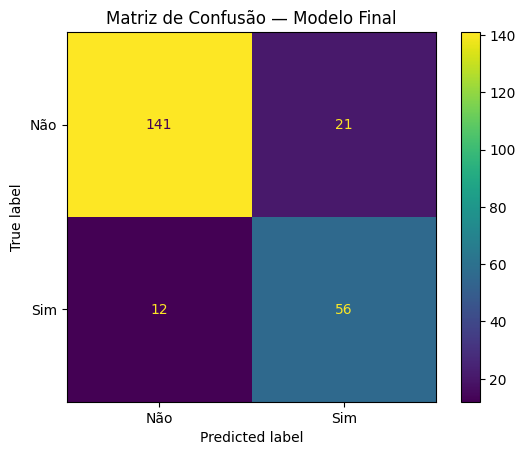

Artefatos salvos em: /content/artefatos_mvp1


In [ ]:
# ======================
# 14. Salvamento de artefatos
# ======================

artefatos_dir = Path("artefatos_mvp1")
artefatos_dir.mkdir(exist_ok=True)

# Salva o pipeline final
joblib.dump(melhor_modelo_rf, artefatos_dir / "pipeline_random_forest_otimizado.pkl")

# Salva tabela de resultados
resultados_final.to_csv(artefatos_dir / "resultados_modelos.csv", index=False)

# Salva resultados do GridSearch
resultados_grid.to_csv(artefatos_dir / "resultados_gridsearch.csv", index=False)

# Salva matriz de confusão como imagem
labels = ["Não", "Sim"]
cm = confusion_matrix(y_test, y_pred_rf_otimizado, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Matriz de Confusão — Modelo Final")
plt.savefig(artefatos_dir / "matriz_confusao_modelo_final.png", dpi=300, bbox_inches="tight")
plt.show()

print("Artefatos salvos em:", artefatos_dir.resolve())

,Variavel,Importancia
1195,cat__Gravidade_Baixo,0.165003
1160,cat__Tipo de Lesão_Sem Lesões,0.135458
1180,cat__Parte do Corpo Atingida_Não se Aplica,0.127974
1196,cat__Gravidade_Médio,0.068166
1131,cat__Agente Causador_Outros,0.033747
1149,cat__Tipo de Lesão_Fratura,0.027351
1,num__Potencial,0.026439
1198,cat__Grau de Risco_Baixo,0.020304
1153,cat__Tipo de Lesão_Luxação,0.014743
1151,cat__Tipo de Lesão_Lesão,0.010091


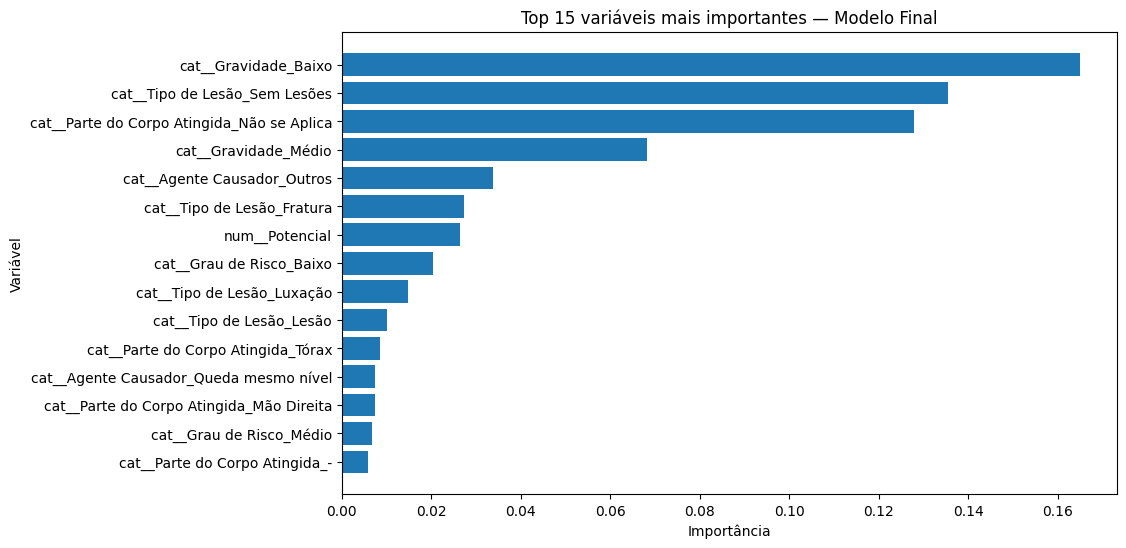

In [ ]:
# Importância das variáveis - Random Forest final
# Observação: após One-Hot Encoding, os nomes das variáveis são expandidos.

try:
    feature_names = melhor_modelo_rf.named_steps["preprocessamento"].get_feature_names_out()
    importancias = melhor_modelo_rf.named_steps["modelo"].feature_importances_

    importancia_variaveis = pd.DataFrame({
        "Variavel": feature_names,
        "Importancia": importancias
    }).sort_values("Importancia", ascending=False)

    display(importancia_variaveis.head(20))

    importancia_variaveis.to_csv(artefatos_dir / "importancia_variaveis.csv", index=False)

    plt.figure(figsize=(10, 6))
    top_imp = importancia_variaveis.head(15).sort_values("Importancia")
    plt.barh(top_imp["Variavel"], top_imp["Importancia"])
    plt.title("Top 15 variáveis mais importantes — Modelo Final")
    plt.xlabel("Importância")
    plt.ylabel("Variável")
    plt.savefig(artefatos_dir / "importancia_variaveis.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("Não foi possível calcular importância das variáveis:", e)

# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Não foram utilizadas técnicas de Deep Learning neste projeto. A base é composta por dados tabulares e possui volume moderado, cenário em que modelos clássicos como Regressão Logística e Random Forest tendem a ser mais adequados, interpretáveis e eficientes.

Deep Learning poderia ser considerado em trabalhos futuros caso houvesse maior volume de dados, variáveis não estruturadas, textos, imagens ou séries temporais complexas. Também poderiam ser testados métodos avançados como XGBoost, LightGBM, CatBoost, AutoML e técnicas de interpretabilidade como SHAP e LIME.

Para o escopo deste MVP, um modelo clássico bem avaliado é mais apropriado do que uma solução complexa sem ganho claro de desempenho.

# Checklist final do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ *(substituir DATA_URL antes da entrega)* |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Pelo menos dois modelos/abordagens comparados | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ✅ |
| Avaliação com métricas coerentes com o problema | ✅ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |